In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
listings = pd.read_csv('../data/raw/listings.csv.gz')
calendar = pd.read_csv('../data/raw/calendar.csv.gz')
reviews = pd.read_csv('../data/raw/reviews.csv.gz')

print(f"Listings: {listings.shape}")
print(f"Calendar: {calendar.shape}")
print(f"Reviews: {reviews.shape}")

Listings: (28806, 79)
Calendar: (10514202, 7)
Reviews: (583333, 6)


In [9]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 28806 entries, 0 to 28805
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            28806 non-null  int64  
 1   listing_url                                   28806 non-null  str    
 2   scrape_id                                     28806 non-null  int64  
 3   last_scraped                                  28806 non-null  str    
 4   source                                        28806 non-null  str    
 5   name                                          28806 non-null  str    
 6   description                                   28030 non-null  str    
 7   neighborhood_overview                         9484 non-null   str    
 8   picture_url                                   28806 non-null  str    
 9   host_id                                       28806 non-null  int64  
 1

In [10]:
listings.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.880600e+04,2.880600e+04,2.880600e+04,28797.000000,28797.000000,0.0,28806.000000,28806.000000,28806.000000,23217.000000,...,18713.000000,18715.000000,18712.000000,18710.000000,0.0,28806.000000,28806.000000,28806.000000,28806.000000,18716.000000
mean,7.995041e+17,2.025093e+13,2.855787e+08,49.951210,61.527381,NaN,13.744811,100.562735,3.137541,1.398501,...,4.764034,4.780835,4.659068,4.646765,NaN,25.863917,20.405679,5.077796,0.209123,0.970914
std,5.786117e+17,0.000000e+00,2.309697e+08,130.953674,158.921638,NaN,0.040952,0.049999,2.275833,1.045507,...,0.509984,0.507388,0.480889,0.543306,NaN,41.237989,38.104656,18.564435,2.788738,1.475826
min,2.793400e+04,2.025093e+13,2.144700e+04,0.000000,0.000000,NaN,13.529370,100.328924,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,4.021719e+07,2.025093e+13,6.287592e+07,3.000000,4.000000,NaN,13.720365,100.530980,2.000000,1.000000,...,4.750000,4.790000,4.557500,4.580000,NaN,2.000000,0.000000,0.000000,0.000000,0.180000
50%,9.946583e+17,2.025093e+13,2.258827e+08,10.000000,12.000000,NaN,13.739550,100.566040,2.000000,1.000000,...,4.920000,4.950000,4.780000,4.790000,NaN,8.000000,3.000000,0.000000,0.000000,0.500000
75%,1.314730e+18,2.025093e+13,5.092574e+08,45.000000,54.000000,NaN,13.758728,100.585742,4.000000,1.500000,...,5.000000,5.000000,5.000000,5.000000,NaN,34.000000,24.000000,3.000000,0.000000,1.260000
max,1.518168e+18,2.025093e+13,7.206394e+08,1455.000000,8774.000000,NaN,13.953540,100.923710,16.000000,50.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,243.000000,234.000000,193.000000,58.000000,57.600000


In [12]:
# Fix price column (remove $ and commas, convert to float)
listings['price'] = listings['price'].replace('[\$,]', '', regex=True).astype(float)

# Fix rate columns
listings['host_response_rate'] = listings['host_response_rate'].replace('%', '', regex=True).astype(float)
listings['host_acceptance_rate'] = listings['host_acceptance_rate'].replace('%', '', regex=True).astype(float)

<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/vb/17bhrkpx2356srtvn_ldhvw40000gn/T/ipykernel_50840/1051245258.py:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  listings['price'] = listings['price'].replace('[\$,]', '', regex=True).astype(float)


In [13]:
# Convert host_since to datetime
listings['host_since'] = pd.to_datetime(listings['host_since'])

# Drop extreme price outliers (keep 1st–99th percentile)
q_low = listings['price'].quantile(0.01)
q_high = listings['price'].quantile(0.99)
listings = listings[(listings['price'] >= q_low) & (listings['price'] <= q_high)]

print(f"Listings after outlier removal: {listings.shape[0]}")
listings[['price', 'host_response_rate', 'host_acceptance_rate']].describe()

Listings after outlier removal: 22807


,price,host_response_rate,host_acceptance_rate
count,22807.000000,20132.000000,21152.000000
mean,1954.639014,92.985148,84.544251
std,1862.679365,20.988275,27.115131
min,341.000000,0.000000,0.000000
25%,935.000000,100.000000,83.000000
50%,1379.000000,100.000000,99.000000
75%,2185.000000,100.000000,100.000000
max,16650.000000,100.000000,100.000000


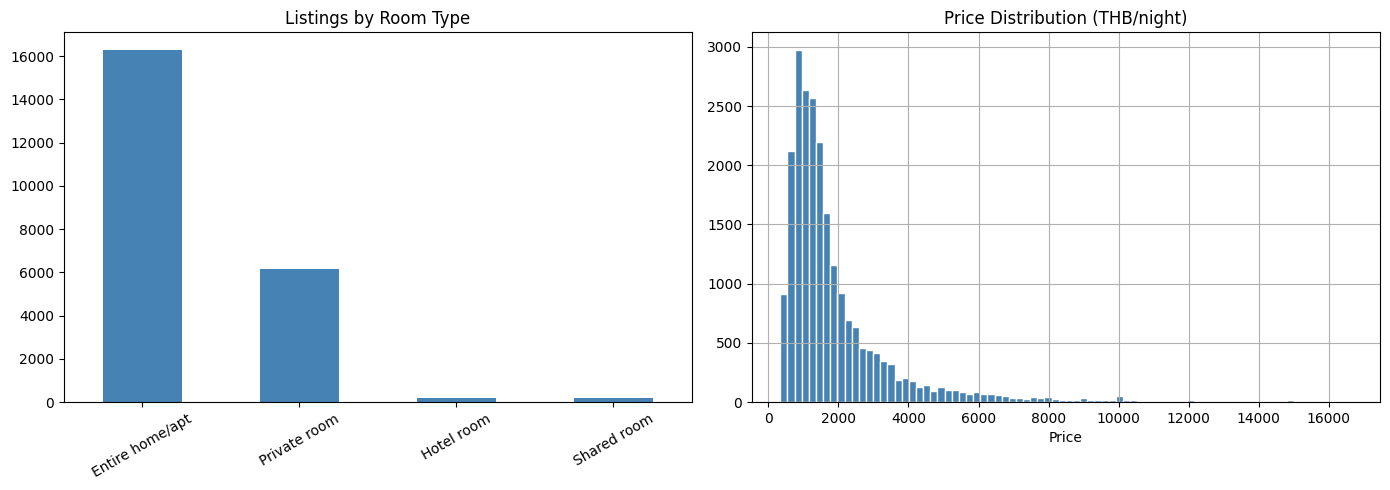

In [21]:
# Room type breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

listings['room_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Listings by Room Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

listings['price'].hist(bins=80, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Price Distribution (THB/night)')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.savefig('../outputs/figures/market_overview.png', dpi=150)
plt.show()

In [17]:
superhost = listings[listings['host_is_superhost'] == 't']
regular = listings[listings['host_is_superhost'] == 'f']

comparison = pd.DataFrame({
    'Superhost': [superhost['price'].median(), superhost['review_scores_rating'].mean(), len(superhost)],
    'Regular': [regular['price'].median(), regular['review_scores_rating'].mean(), len(regular)]
}, index=['Median Price (THB)', 'Avg Review Score', 'Count'])

print(comparison.round(2))

                    Superhost  Regular
Median Price (THB)    1390.00   1371.0
Avg Review Score         4.86      4.6
Count                 7309.00  14053.0


/var/folders/vb/17bhrkpx2356srtvn_ldhvw40000gn/T/ipykernel_50840/3944130124.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_neighbourhoods, x='count', y='neighbourhood', palette='Blues_r')


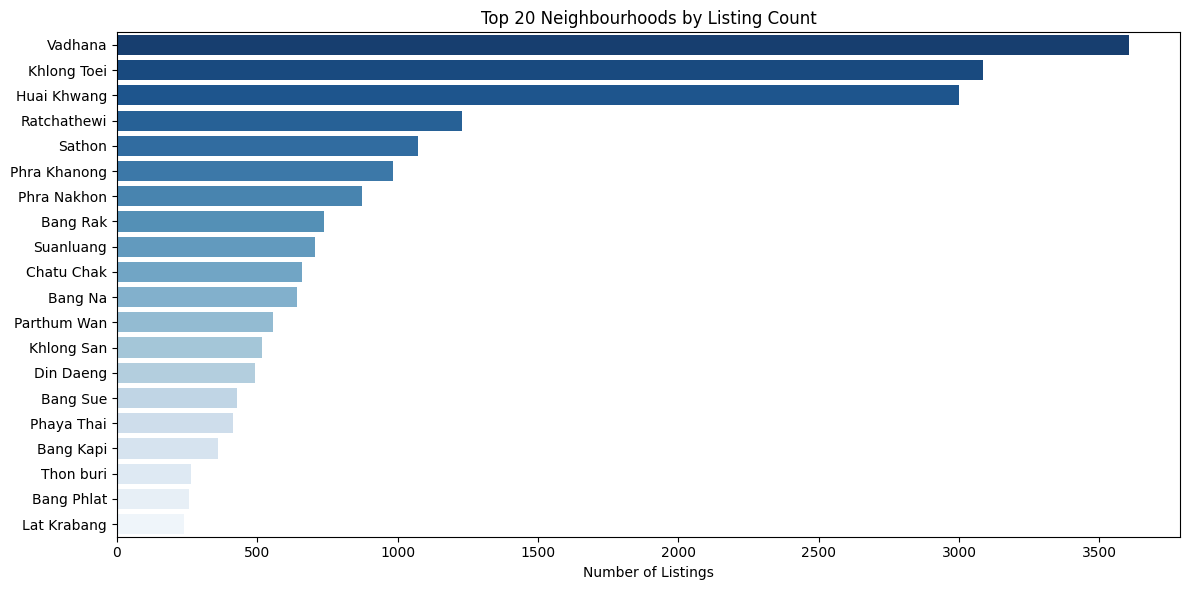

In [20]:
# Top 20 neighbourhoods by listing count
top_neighbourhoods = (
    listings['neighbourhood_cleansed']
    .value_counts()
    .head(20)
    .reset_index()
)
top_neighbourhoods.columns = ['neighbourhood', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_neighbourhoods, x='count', y='neighbourhood', palette='Blues_r')
plt.title('Top 20 Neighbourhoods by Listing Count')
plt.xlabel('Number of Listings')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/neighbourhood_counts.png', dpi=150)
plt.show()

/var/folders/vb/17bhrkpx2356srtvn_ldhvw40000gn/T/ipykernel_50840/1394042745.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_by_neighbourhood, x='median_price', y='neighbourhood', palette='Oranges_r')


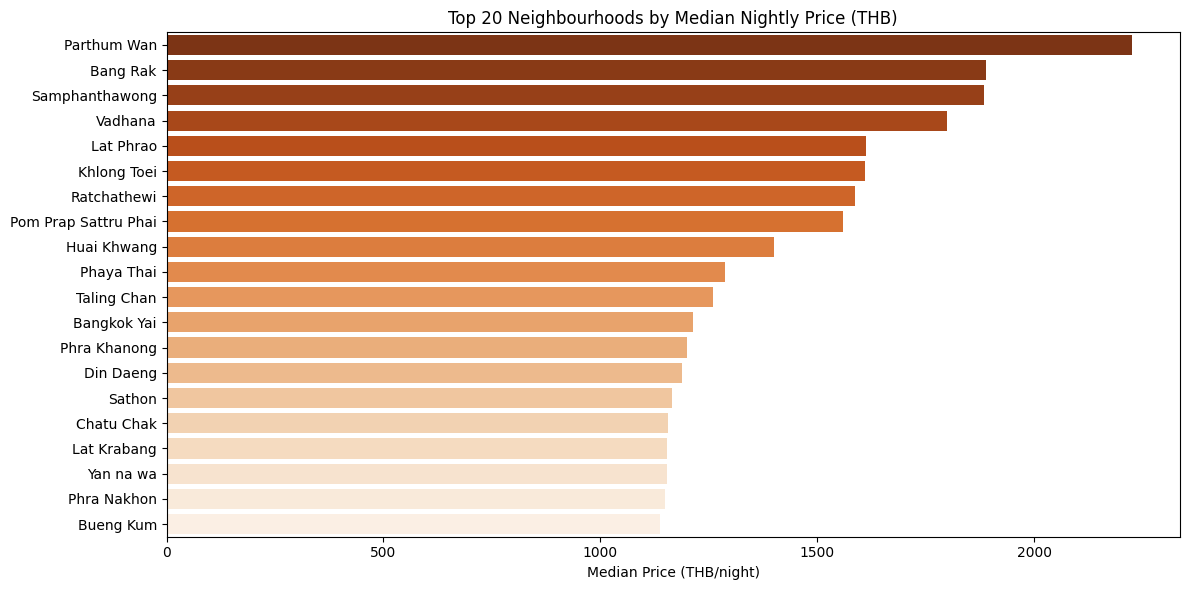

In [22]:
# Top 20 neighbourhoods by median price (min 10 listings)
price_by_neighbourhood = (
    listings.groupby('neighbourhood_cleansed')['price']
    .agg(['median', 'count'])
    .reset_index()
    .query('count >= 10')
    .sort_values('median', ascending=False)
    .head(20)
)
price_by_neighbourhood.columns = ['neighbourhood', 'median_price', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=price_by_neighbourhood, x='median_price', y='neighbourhood', palette='Oranges_r')
plt.title('Top 20 Neighbourhoods by Median Nightly Price (THB)')
plt.xlabel('Median Price (THB/night)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/neighbourhood_prices.png', dpi=150)
plt.show()